In [2]:
import pandas as pd

In [3]:
# Column names from Freddie Mac documentation
ORIG_COLUMNS = [
    "credit_score", "first_payment_date", "first_time_homebuyer",
    "maturity_date", "msa", "mi_pct", "num_units", "occupancy",
    "cltv", "dti", "original_upb", "ltv", "original_interest_rate",
    "channel", "ppm_flag", "product_type", "property_state",
    "property_type", "postal_code", "loan_sequence_number",
    "loan_purpose", "original_loan_term", "num_borrowers",
    "seller_name", "servicer_name", "super_conforming_flag",
    "pre_harp_loan_seq_num", "program_indicator", "harp_indicator",
    "property_valuation_method", "io_indicator", "mi_cancellation_indicator"
]

In [4]:
df = pd.read_csv(
    "data/sample_2019/sample_orig_2019.txt",
    sep="|",
    header=None,
    names=ORIG_COLUMNS,low_memory=False
)
df.head()

,credit_score,first_payment_date,first_time_homebuyer,maturity_date,msa,mi_pct,num_units,occupancy,cltv,dti,...,num_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_seq_num,program_indicator,harp_indicator,property_valuation_method,io_indicator,mi_cancellation_indicator
0,741,201903,N,204902,NaN,0,1,P,80,33,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7
1,731,201903,N,204902,13460.0,0,1,P,77,44,...,1,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7
2,722,201903,N,204902,NaN,30,1,P,95,41,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,N
3,729,201903,N,204902,NaN,25,1,P,87,17,...,1,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,N
4,773,201903,N,204902,33700.0,0,1,P,29,43,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7


In [5]:
df.shape

(50000, 32)

In [6]:
df[["credit_score","original_interest_rate", "original_upb", "ltv", "dti", "property_state"]].head(10)

,credit_score,original_interest_rate,original_upb,ltv,dti,property_state
0,741,5.125,372000,80,33,WY
1,731,4.875,250000,77,44,OR
2,722,5.500,261000,95,41,IN
3,729,5.090,61000,87,17,MI
4,773,5.375,390000,29,43,CA
5,780,4.750,392000,90,47,CO
6,782,5.125,316000,80,34,KY
7,772,4.375,212000,80,29,IL
8,708,5.125,226000,80,22,OH
9,744,5.125,86000,57,39,MI


In [7]:
df[["credit_score","original_interest_rate", "original_upb", "ltv", "dti"]].describe()

,credit_score,original_interest_rate,original_upb,ltv,dti
count,50000.00000,50000.000000,5.000000e+04,50000.000000,50000.000000
mean,752.72134,4.237770,2.545748e+05,75.644580,35.912040
std,180.90233,0.586342,1.300801e+05,16.811197,25.753408
min,562.00000,2.350000,1.500000e+04,5.000000,1.000000
25%,719.00000,3.875000,1.550000e+05,69.000000,29.000000
50%,757.00000,4.125000,2.320000e+05,80.000000,37.000000
75%,785.00000,4.625000,3.350000e+05,90.000000,43.000000
max,9999.00000,6.750000,1.397000e+06,103.000000,999.000000


In [8]:
print((df["ltv"] == 999).sum())
print((df["cltv"] == 999).sum())
print((df["mi_pct"] == 999).sum())
print((df["num_borrowers"] == 99).sum())

0
1
0
0


In [9]:
import numpy as np

# Replace sentinel value with NaN (missing)
df["credit_score"]=df["credit_score"].replace(9999,np.nan)
df["dti"]=df["dti"].replace(999,np.nan)
df["cltv"]=df["cltv"].replace(999,np.nan)

In [10]:
df[["credit_score","original_interest_rate", "original_upb", "ltv", "dti","cltv"]].describe()

,credit_score,original_interest_rate,original_upb,ltv,dti,cltv
count,49982.000000,50000.000000,5.000000e+04,50000.000000,49969.000000,49999.000000
mean,749.391481,4.237770,2.545748e+05,75.644580,35.314555,75.815376
std,44.010562,0.586342,1.300801e+05,16.811197,9.372853,16.809688
min,562.000000,2.350000,1.500000e+04,5.000000,1.000000,5.000000
25%,719.000000,3.875000,1.550000e+05,69.000000,29.000000,69.000000
50%,757.000000,4.125000,2.320000e+05,80.000000,37.000000,80.000000
75%,785.000000,4.625000,3.350000e+05,90.000000,43.000000,90.000000
max,832.000000,6.750000,1.397000e+06,103.000000,50.000000,105.000000


In [11]:
# Servicing file column names (From freddi documentation)
SVCG_COLUMNS = [
    "loan_sequence_number", "monthly_reporting_period", "current_actual_upb",
    "current_loan_delinquency_status", "loan_age", "remaining_months_to_maturity",
    "defect_settlement_date", "modification_flag", "zero_balance_code",
    "zero_balance_effective_date", "current_interest_rate", "current_deferred_upb",
    "ddlpi", "mi_recoveries", "net_sales_proceeds", "non_mi_recoveries",
    "total_expenses", "legal_costs", "maintenance_and_preservation_costs",
    "taxes_and_insurance", "miscellaneous_expenses", "actual_loss_calculation",
    "modification_cost", "step_modification_flag", "deferred_payment_plan",
    "estimated_loan_to_value", "zero_balance_removal_upb", "delinquent_accrued_interest",
    "delinquency_due_to_disaster", "borrower_assistance_status_code",
    "current_month_modification_cost", "interest_bearing_upb"
]

svcg=pd.read_csv(
    "data/sample_2019/sample_svcg_2019.txt",
    sep="|",
    header=None,
    names=SVCG_COLUMNS,low_memory=False
)
print(f" Number of rows:{len(svcg):,}")
print(f" Number of columns:{len(svcg.columns)}")


 Number of rows:1,847,477
 Number of columns:32


In [12]:
svcg.head()

,loan_sequence_number,monthly_reporting_period,current_actual_upb,current_loan_delinquency_status,loan_age,remaining_months_to_maturity,defect_settlement_date,modification_flag,zero_balance_code,zero_balance_effective_date,...,modification_cost,step_modification_flag,deferred_payment_plan,estimated_loan_to_value,zero_balance_removal_upb,delinquent_accrued_interest,delinquency_due_to_disaster,borrower_assistance_status_code,current_month_modification_cost,interest_bearing_upb
0,F19Q10000056,201902,372000.0,0,0,360,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,999,NaN,NaN,NaN,NaN,NaN,372000.0
1,F19Q10000056,201903,372000.0,0,1,359,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,999,NaN,NaN,NaN,NaN,NaN,372000.0
2,F19Q10000056,201904,371000.0,0,2,358,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,999,NaN,NaN,NaN,NaN,NaN,371000.0
3,F19Q10000056,201905,370000.0,0,3,357,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,999,NaN,NaN,NaN,NaN,NaN,370000.0
4,F19Q10000056,201906,370000.0,0,4,356,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,75,NaN,NaN,NaN,NaN,NaN,370000.0


In [13]:
svcg["zero_balance_code"].value_counts(dropna=False)

zero_balance_code
NaN     1812215
1.0       35073
96.0        123
16.0         30
2.0          16
9.0          10
15.0          7
3.0           3
Name: count, dtype: int64

In [14]:
prepayments=svcg[svcg["zero_balance_code"]==1.0].copy()
print(f"Number of prepayment events: {len(prepayments):,}")
prepayments[["loan_sequence_number", "monthly_reporting_period", "loan_age", "current_actual_upb"]].head(10)

Number of prepayment events: 35,073


,loan_sequence_number,monthly_reporting_period,loan_age,current_actual_upb
38,F19Q10000056,202204,38,0.0
54,F19Q10000060,202005,15,0.0
69,F19Q10000084,202004,14,0.0
86,F19Q10000106,202006,16,0.0
104,F19Q10000189,202007,17,0.0
110,F19Q10000231,201907,5,0.0
121,F19Q10000239,201912,10,0.0
128,F19Q10000244,201908,6,0.0
140,F19Q10000248,202001,11,0.0
175,F19Q10000268,202112,34,0.0


In [15]:
# Merge servicing with origination data
combined=pd.merge(svcg,df[["loan_sequence_number", "credit_score", "original_interest_rate", 
        "original_upb", "ltv", "dti", "property_state", "loan_purpose",
        "first_payment_date"]],on="loan_sequence_number",how="left")

print(f"Combined shape: {combined.shape}")
combined.head(10)

Combined shape: (1847477, 40)


,loan_sequence_number,monthly_reporting_period,current_actual_upb,current_loan_delinquency_status,loan_age,remaining_months_to_maturity,defect_settlement_date,modification_flag,zero_balance_code,zero_balance_effective_date,...,current_month_modification_cost,interest_bearing_upb,credit_score,original_interest_rate,original_upb,ltv,dti,property_state,loan_purpose,first_payment_date
0,F19Q10000056,201902,372000.00,0,0,360,NaN,NaN,NaN,NaN,...,NaN,372000.00,741.0,5.125,372000,80,33.0,WY,P,201903
1,F19Q10000056,201903,372000.00,0,1,359,NaN,NaN,NaN,NaN,...,NaN,372000.00,741.0,5.125,372000,80,33.0,WY,P,201903
2,F19Q10000056,201904,371000.00,0,2,358,NaN,NaN,NaN,NaN,...,NaN,371000.00,741.0,5.125,372000,80,33.0,WY,P,201903
3,F19Q10000056,201905,370000.00,0,3,357,NaN,NaN,NaN,NaN,...,NaN,370000.00,741.0,5.125,372000,80,33.0,WY,P,201903
4,F19Q10000056,201906,370000.00,0,4,356,NaN,NaN,NaN,NaN,...,NaN,370000.00,741.0,5.125,372000,80,33.0,WY,P,201903
5,F19Q10000056,201907,369000.00,0,5,355,NaN,NaN,NaN,NaN,...,NaN,369000.00,741.0,5.125,372000,80,33.0,WY,P,201903
6,F19Q10000056,201908,369000.00,0,6,354,NaN,NaN,NaN,NaN,...,NaN,369000.00,741.0,5.125,372000,80,33.0,WY,P,201903
7,F19Q10000056,201909,368239.58,0,7,353,NaN,NaN,NaN,NaN,...,NaN,368239.58,741.0,5.125,372000,80,33.0,WY,P,201903
8,F19Q10000056,201910,367678.69,0,8,352,NaN,NaN,NaN,NaN,...,NaN,367678.69,741.0,5.125,372000,80,33.0,WY,P,201903
9,F19Q10000056,201911,367216.67,0,9,351,NaN,NaN,NaN,NaN,...,NaN,367216.67,741.0,5.125,372000,80,33.0,WY,P,201903


In [16]:
# Average original rate of loans that prepaid vs still alive
prepaid_loans=combined[combined["zero_balance_code"]==1]
still_alive=combined[combined['zero_balance_code'].isna()]
print(f"Avg original rate of PREPAID loans: {prepaid_loans["original_interest_rate"].mean():.3f}%")
print(f"Avg original rate of PREPAID loans: {still_alive["original_interest_rate"].mean():.3f}%")

Avg original rate of PREPAID loans: 4.273%
Avg original rate of PREPAID loans: 4.215%


In [17]:
import pandas_datareader.data as web
from datetime import datetime

In [18]:
# Fetch 30 yr US mortgage data from FRED
#start=datetime(2018,1,1)
#end=datetime(2024,12,31)

In [19]:
#mortgage_rates=web.DataReader("MORTGAGE30US","fred",start,end)
#print(f"Shape:{mortgage_rates.shape}")
#mortgage_rates.head(10)

In [20]:
# Historical 30-year fixed mortgage rate (monthly avg, %), 2018-2024
# Source: Freddie Mac PMMS via FRED MORTGAGE30US
mortgage_rate_history = {
    "2018-01": 4.03, "2018-02": 4.33, "2018-03": 4.44, "2018-04": 4.47,
    "2018-05": 4.59, "2018-06": 4.57, "2018-07": 4.53, "2018-08": 4.55,
    "2018-09": 4.63, "2018-10": 4.83, "2018-11": 4.87, "2018-12": 4.64,
    "2019-01": 4.46, "2019-02": 4.37, "2019-03": 4.27, "2019-04": 4.14,
    "2019-05": 4.07, "2019-06": 3.80, "2019-07": 3.77, "2019-08": 3.62,
    "2019-09": 3.61, "2019-10": 3.69, "2019-11": 3.70, "2019-12": 3.72,
    "2020-01": 3.62, "2020-02": 3.47, "2020-03": 3.45, "2020-04": 3.31,
    "2020-05": 3.23, "2020-06": 3.16, "2020-07": 3.02, "2020-08": 2.94,
    "2020-09": 2.89, "2020-10": 2.83, "2020-11": 2.77, "2020-12": 2.68,
    "2021-01": 2.74, "2021-02": 2.81, "2021-03": 3.08, "2021-04": 3.06,
    "2021-05": 2.96, "2021-06": 2.98, "2021-07": 2.87, "2021-08": 2.84,
    "2021-09": 2.90, "2021-10": 3.07, "2021-11": 3.07, "2021-12": 3.10,
    "2022-01": 3.45, "2022-02": 3.76, "2022-03": 4.17, "2022-04": 4.98,
    "2022-05": 5.23, "2022-06": 5.52, "2022-07": 5.41, "2022-08": 5.22,
    "2022-09": 6.11, "2022-10": 6.90, "2022-11": 6.81, "2022-12": 6.36,
    "2023-01": 6.27, "2023-02": 6.26, "2023-03": 6.54, "2023-04": 6.34,
    "2023-05": 6.43, "2023-06": 6.71, "2023-07": 6.84, "2023-08": 7.07,
    "2023-09": 7.20, "2023-10": 7.62, "2023-11": 7.44, "2023-12": 6.82,
    "2024-01": 6.64, "2024-02": 6.78, "2024-03": 6.82, "2024-04": 6.99,
    "2024-05": 7.06, "2024-06": 6.92, "2024-07": 6.85, "2024-08": 6.50,
    "2024-09": 6.18, "2024-10": 6.43, "2024-11": 6.81, "2024-12": 6.72
}

mortgage_rates=pd.DataFrame(list(mortgage_rate_history.items()),columns=["year_month","market rate"])
print(f"Shape:{mortgage_rates.shape}")
mortgage_rates.head(10)

Shape:(84, 2)


,year_month,market rate
0,2018-01,4.03
1,2018-02,4.33
2,2018-03,4.44
3,2018-04,4.47
4,2018-05,4.59
5,2018-06,4.57
6,2018-07,4.53
7,2018-08,4.55
8,2018-09,4.63
9,2018-10,4.83


In [21]:
combined["year_month"]=combined['monthly_reporting_period'].astype(str).str[:4]+"-" + combined['monthly_reporting_period'].astype(str).str[4:6]
combined[["monthly_reporting_period","year_month"]].head(10)

,monthly_reporting_period,year_month
0,201902,2019-02
1,201903,2019-03
2,201904,2019-04
3,201905,2019-05
4,201906,2019-06
5,201907,2019-07
6,201908,2019-08
7,201909,2019-09
8,201910,2019-10
9,201911,2019-11


In [22]:
# Merge market rates into combined
combined=pd.merge(combined,mortgage_rates,on="year_month",how='left')

# Verify market_rate is now populated
combined[["loan_sequence_number", "monthly_reporting_period", "year_month", "original_interest_rate", "market rate"]].head(10)

,loan_sequence_number,monthly_reporting_period,year_month,original_interest_rate,market rate
0,F19Q10000056,201902,2019-02,5.125,4.37
1,F19Q10000056,201903,2019-03,5.125,4.27
2,F19Q10000056,201904,2019-04,5.125,4.14
3,F19Q10000056,201905,2019-05,5.125,4.07
4,F19Q10000056,201906,2019-06,5.125,3.80
5,F19Q10000056,201907,2019-07,5.125,3.77
6,F19Q10000056,201908,2019-08,5.125,3.62
7,F19Q10000056,201909,2019-09,5.125,3.61
8,F19Q10000056,201910,2019-10,5.125,3.69
9,F19Q10000056,201911,2019-11,5.125,3.70


In [23]:
# rate incentive (note rate - current market rate)
combined['rate_incentive']=combined['original_interest_rate']-combined['market rate']
combined[["loan_sequence_number", "monthly_reporting_period", "year_month", "original_interest_rate", "market rate","rate_incentive"]].head(10)

,loan_sequence_number,monthly_reporting_period,year_month,original_interest_rate,market rate,rate_incentive
0,F19Q10000056,201902,2019-02,5.125,4.37,0.755
1,F19Q10000056,201903,2019-03,5.125,4.27,0.855
2,F19Q10000056,201904,2019-04,5.125,4.14,0.985
3,F19Q10000056,201905,2019-05,5.125,4.07,1.055
4,F19Q10000056,201906,2019-06,5.125,3.80,1.325
5,F19Q10000056,201907,2019-07,5.125,3.77,1.355
6,F19Q10000056,201908,2019-08,5.125,3.62,1.505
7,F19Q10000056,201909,2019-09,5.125,3.61,1.515
8,F19Q10000056,201910,2019-10,5.125,3.69,1.435
9,F19Q10000056,201911,2019-11,5.125,3.70,1.425


In [24]:
combined['rate_incentive'].describe()

count    1.710570e+06
mean    -1.139890e-01
std      1.728928e+00
min     -5.270000e+00
25%     -1.740000e+00
50%      5.400000e-01
75%      1.140000e+00
max      4.070000e+00
Name: rate_incentive, dtype: float64

In [25]:
# Building the ML target 

combined['obs_date']=pd.to_datetime(combined["monthly_reporting_period"],format="%Y%m")

# for every loan find the date it prepaid

prepay_dates=combined[combined["zero_balance_code"]==1][["loan_sequence_number","obs_date"]].rename(columns={"obs_date":"prepay_date"})

print(f"Total prepay events: {len(prepay_dates):,}")

Total prepay events: 35,073


In [26]:
# Add prepay date to combined data

combined=pd.merge(combined,prepay_dates,on="loan_sequence_number",how="left")

combined.head(10)

,loan_sequence_number,monthly_reporting_period,current_actual_upb,current_loan_delinquency_status,loan_age,remaining_months_to_maturity,defect_settlement_date,modification_flag,zero_balance_code,zero_balance_effective_date,...,ltv,dti,property_state,loan_purpose,first_payment_date,year_month,market rate,rate_incentive,obs_date,prepay_date
0,F19Q10000056,201902,372000.00,0,0,360,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-02,4.37,0.755,2019-02-01,2022-04-01
1,F19Q10000056,201903,372000.00,0,1,359,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-03,4.27,0.855,2019-03-01,2022-04-01
2,F19Q10000056,201904,371000.00,0,2,358,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-04,4.14,0.985,2019-04-01,2022-04-01
3,F19Q10000056,201905,370000.00,0,3,357,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-05,4.07,1.055,2019-05-01,2022-04-01
4,F19Q10000056,201906,370000.00,0,4,356,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-06,3.80,1.325,2019-06-01,2022-04-01
5,F19Q10000056,201907,369000.00,0,5,355,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-07,3.77,1.355,2019-07-01,2022-04-01
6,F19Q10000056,201908,369000.00,0,6,354,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-08,3.62,1.505,2019-08-01,2022-04-01
7,F19Q10000056,201909,368239.58,0,7,353,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-09,3.61,1.515,2019-09-01,2022-04-01
8,F19Q10000056,201910,367678.69,0,8,352,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-10,3.69,1.435,2019-10-01,2022-04-01
9,F19Q10000056,201911,367216.67,0,9,351,NaN,NaN,NaN,NaN,...,80,33.0,WY,P,201903,2019-11,3.70,1.425,2019-11-01,2022-04-01


In [27]:
combined["months_to_prepay"]=((combined["prepay_date"]-combined["obs_date"]).dt.days/30.44).round()

combined[combined["loan_sequence_number"]=="F19Q10000056"][["obs_date","prepay_date","months_to_prepay"]].head(15)

,obs_date,prepay_date,months_to_prepay
0,2019-02-01,2022-04-01,38.0
1,2019-03-01,2022-04-01,37.0
2,2019-04-01,2022-04-01,36.0
3,2019-05-01,2022-04-01,35.0
4,2019-06-01,2022-04-01,34.0
5,2019-07-01,2022-04-01,33.0
6,2019-08-01,2022-04-01,32.0
7,2019-09-01,2022-04-01,31.0
8,2019-10-01,2022-04-01,30.0
9,2019-11-01,2022-04-01,29.0


In [28]:
# Did the loan prepay in next 12 months

combined["prepay_in_12m"]=((combined["months_to_prepay"]>=1)& (combined["months_to_prepay"]<=12)).astype(int)

combined[combined["loan_sequence_number"]=="F19Q10000056"][["obs_date", "prepay_date", "months_to_prepay", "prepay_in_12m"]].iloc[20:40]

,obs_date,prepay_date,months_to_prepay,prepay_in_12m
20,2020-10-01,2022-04-01,18.0,0
21,2020-11-01,2022-04-01,17.0,0
22,2020-12-01,2022-04-01,16.0,0
23,2021-01-01,2022-04-01,15.0,0
24,2021-02-01,2022-04-01,14.0,0
25,2021-03-01,2022-04-01,13.0,0
26,2021-04-01,2022-04-01,12.0,1
27,2021-05-01,2022-04-01,11.0,1
28,2021-06-01,2022-04-01,10.0,1
29,2021-07-01,2022-04-01,9.0,1


In [29]:
print(f'total rows:{len(combined):,}')
print(f"Positive labels (prepay in 12m): {combined['prepay_in_12m'].sum():,}")
print(f"Positive rate: {combined['prepay_in_12m'].mean():.2%}")

total rows:1,847,477
Positive labels (prepay in 12m): 385,657
Positive rate: 20.87%


In [30]:
# keep only rows before prepayment (or loan never prepaid )
training = combined[
    (combined["prepay_date"].isna()) |
    (combined["obs_date"] < combined["prepay_date"])].copy()

print(f"After 1st filter: {len(training):,}")

After 1st filter: 1,812,404


In [31]:
# Filter 2: dropping observation for whihc we don't have 12 m forward data 
    
latest_date=combined["obs_date"].max()
print(latest_date)

2025-09-01 00:00:00


In [32]:
# cut off 12 m before max date
from pandas import Timedelta
cutoff_date=latest_date-pd.DateOffset(months=12)
print(cutoff_date)

2024-09-01 00:00:00


In [33]:
mask=(( training ["obs_date"]<=cutoff_date)|training['prepay_date'].notna())

In [34]:
training=training[mask].copy()
print(len(training))

1635432


In [35]:
# Required features for the model
Required_features=[
    "credit_score", "original_interest_rate", "original_upb",
    "ltv", "dti", "loan_age", "market rate", "rate_incentive"
]

In [36]:
# Drop rows where any required features is na
before=len(training)
training=training.dropna(subset=Required_features).copy()
after=len(training)

In [37]:
print (before) 
print (after)

1635432
1629782


In [38]:
print(f"Positive rate: {training['prepay_in_12m'].mean(): .2%}")

Positive rate:  23.44%


In [39]:
import numpy as np

In [40]:
def psa_cpr(loan_age):
    return np.where(loan_age<30,0.06*(loan_age/30),0.06)

# quick check
test_ages=[0,6,15,25,30,45,60,120]

for i in test_ages:
    print(f'Loan age {i} months -> PSA CPR ={psa_cpr(i):.2%}')

Loan age 0 months -> PSA CPR =0.00%
Loan age 6 months -> PSA CPR =1.20%
Loan age 15 months -> PSA CPR =3.00%
Loan age 25 months -> PSA CPR =5.00%
Loan age 30 months -> PSA CPR =6.00%
Loan age 45 months -> PSA CPR =6.00%
Loan age 60 months -> PSA CPR =6.00%
Loan age 120 months -> PSA CPR =6.00%


In [41]:
# compute PSA_CPR on training data
training["psa_predicted_cpr"]=psa_cpr(training['loan_age'])

print(training[['loan_age','psa_predicted_cpr','prepay_in_12m']].head(10))


   loan_age  psa_predicted_cpr  prepay_in_12m
0         0              0.000              0
1         1              0.002              0
2         2              0.004              0
3         3              0.006              0
4         4              0.008              0
5         5              0.010              0
6         6              0.012              0
7         7              0.014              0
8         8              0.016              0
9         9              0.018              0


In [42]:
print(f'PSA mean :{training['psa_predicted_cpr'].mean():.2%}')
print(f"Actual prepayment : {training['prepay_in_12m'].mean(): .2%}")


PSA mean :3.63%
Actual prepayment :  23.44%


In [43]:
from sklearn.metrics import mean_squared_error

# PSA RMSE on training data

psa_rmse=np.sqrt(mean_squared_error(training['prepay_in_12m'],training['psa_predicted_cpr']))

print(f'PSA RMSE:{psa_rmse:.4f}')
print(f'If we used average prepay speed assumption for every loan RMSE= {np.sqrt(training['prepay_in_12m'].var()):.2f}')


# split data
split_date=pd.to_datetime("2023-01-01")

train_df=training[training["obs_date"]<split_date].copy()
test_df=training[training["obs_date"]>=split_date].copy()

print(f'Training rows:{len(train_df):,} ({train_df['prepay_in_12m'].mean():,.2%} positive)')
print(f'Test rows:{len(test_df):,} ({test_df['prepay_in_12m'].mean():,.2%} positive)')

In [44]:
import xgboost as xgb

features=["credit_score", "original_interest_rate", "original_upb",
          "ltv", "dti", "loan_age", "market rate", "rate_incentive"]





x_train=train_df[features]
y_train=train_df["prepay_in_12m"]

x_test=test_df[features]
y_test=test_df["prepay_in_12m"]

print(x_train.shape)
print(x_test.shape)

model=xgb.XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=20,n_jobs=-1,eval_metric="logloss")

print("Training the model....")
model.fit(x_train,y_train)
print("Done!")


# predict on test data
test_df["xgb_pred"]=model.predict_proba(x_test)[:,1]

# check

test_df[["loan_age","rate_incentive","psa_predicted_cpr","xgb_pred","prepay_in_12m"]].head(10)


# looking at high incentive loan 

high_incentive=test_df[test_df["rate_incentive"]>0][["loan_age","rate_incentive","psa_predicted_cpr","xgb_pred","prepay_in_12m"]].head(10)
print(high_incentive)
len(high_incentive)

In [45]:
training["year"]=training["obs_date"].dt.year
training.groupby("year")["rate_incentive"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2019,259117.0,0.682812,0.550171,-1.345,0.300,0.655,1.030,3.14
2020,486555.0,1.050850,0.651540,-1.245,0.580,1.005,1.445,4.07
2021,304632.0,1.238079,0.618981,-0.750,0.805,1.150,1.635,4.01
2022,225288.0,-1.118895,1.245293,-4.550,-2.025,-1.230,-0.200,3.30
2023,206031.0,-2.630431,0.746762,-5.270,-3.145,-2.665,-2.165,0.49
2024,148159.0,-2.594642,0.655067,-4.710,-3.060,-2.670,-2.185,0.57


In [46]:
# re-split data from 2021. We want to validate if our model prediction is close to actual and hence we take test data of 2021 which has good rate_incen


split_date=pd.to_datetime("2021-01-01")

train_df=training[training["obs_date"]<split_date].copy()
test_df=training[(training["obs_date"]>="2021-01-01") & (training["obs_date"]<="2021-12-31")].copy()

print(f'Training rows:{len(train_df):,} ({train_df['prepay_in_12m'].mean():,.2%} positive)')
print(f'Test rows:{len(test_df):,} ({test_df['prepay_in_12m'].mean():,.2%} positive)')

Training rows:745,672 (34.65% positive)
Test rows:304,632 (26.00% positive)


In [47]:
x_train=train_df[features]
y_train=train_df['prepay_in_12m']
x_test=test_df[features]
y_test=test_df['prepay_in_12m']

In [48]:
model=xgb.XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=20,n_jobs=-1,eval_metric="logloss")

print("Training the model....")
model.fit(x_train,y_train)
print("Done!")

Training the model....
Done!


In [49]:
from sklearn.metrics import mean_squared_error

# Predition
test_df["xgb_pred"]=model.predict_proba(x_test)[:,1]

# Compute RMSE

xgb_rmse=np.sqrt(mean_squared_error(y_test,test_df['xgb_pred']))
psa_rmse=np.sqrt(mean_squared_error(y_test,test_df['psa_predicted_cpr']))

print(f'PSA RMSE:{psa_rmse:.2f}')
print(f'XGB RMSE:{xgb_rmse:.2f}')

PSA RMSE:0.49
XGB RMSE:0.46


In [50]:
print(test_df['xgb_pred'].describe())

count    304632.000000
mean          0.401608
std           0.139297
min           0.008110
25%           0.301996
50%           0.398812
75%           0.502804
max           0.901913
Name: xgb_pred, dtype: float64


In [51]:
# Adding Burnout 

combined=combined.sort_values(['loan_sequence_number','obs_date']).copy()

combined['burnout']=(combined.groupby('loan_sequence_number')['rate_incentive'].transform(lambda x: x.shift(1).expanding().max()))

In [52]:
print(combined['burnout'].describe())

count    1.797477e+06
mean     1.257617e+00
std      6.765494e-01
min     -1.325000e+00
25%      8.200000e-01
50%      1.195000e+00
75%      1.695000e+00
max      4.070000e+00
Name: burnout, dtype: float64


In [53]:
combined['month']=combined['obs_date'].dt.month
print(combined['month'].value_counts().sort_index())

month
1     150721
2     151900
3     153217
4     155149
5     155984
6     157307
7     158714
8     159521
9     160367
10    146635
11    148434
12    149528
Name: count, dtype: int64


In [54]:
features=[ "credit_score",
    "original_interest_rate", 
    "original_upb",
    "ltv",
    "dti",
    "loan_age",
    "market rate",
    "rate_incentive",
    "burnout",        
    "month"]

In [55]:
required_features=[ "credit_score",
    "original_interest_rate", 
    "original_upb",
    "ltv",
    "dti",
    "loan_age",
    "market rate",
    "rate_incentive",
    "burnout",        
    "month"]

In [56]:
training=combined[(combined['prepay_date'].isna())|(combined['obs_date']<combined['prepay_date'])].copy()

In [57]:
print(len(training))

1812404


In [58]:
cutoff_date=combined['obs_date'].max()-pd.DateOffset(months=12)

training=training[(training['obs_date']<=cutoff_date)| (training['prepay_date'].notna())].copy()

print(len(training))

1635432


In [59]:
training=training.dropna(subset=required_features).copy()

print(len(training))

1579859


In [60]:
train_df=training[training['obs_date']<"2021-01-01"].copy()

test_df=training[
        (training['obs_date']>="2021-01-01") & 
        (training['obs_date']<="2021-12-31")].copy()

In [61]:
print(f'Train:{len(train_df):,} Positive rate: {train_df['prepay_in_12m'].mean():.2%}')
print(f'Test:{len(test_df):,} Positive rate: {test_df['prepay_in_12m'].mean():.2%}')

Train:695,754 Positive rate: 35.64%
Test:304,627 Positive rate: 26.00%


In [62]:
FEATURES=["credit_score", "original_interest_rate", "original_upb",
           "ltv", "dti", "loan_age", "market rate", "rate_incentive",
            "burnout", "month"]

x_train=train_df[FEATURES]
y_train=train_df["prepay_in_12m"]

x_test=test_df[FEATURES]
y_test=test_df['prepay_in_12m']

model=xgb.XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42,n_jobs=-1,eval_metric="logloss")

print("Training...")
model.fit(x_train,y_train)
print("Done!")

Training...
Done!


In [63]:
from sklearn.metrics import mean_squared_error,roc_auc_score

#XGBoost prediction after adding burnout and seasonality effects

test_df["xgb_pred"]=model.predict_proba(x_test)[:,1]

test_df["psa_pred"]=psa_cpr(test_df['loan_age'])

xgb_rmse=np.sqrt(mean_squared_error(y_test,test_df['xgb_pred']))

psa_rmse=np.sqrt(mean_squared_error(y_test,test_df['psa_pred']))

xgb_auc=roc_auc_score(y_test,test_df['xgb_pred'])

psa_auc=roc_auc_score(y_test,test_df['psa_pred'])


print(f'XGB_RMSE:{xgb_rmse:.2}')
print(f'PSA_RMSE:{psa_rmse:.2}')
print(f'XGB_AUC:{xgb_auc:.2}')
print(f'PSA_AUC:{psa_auc:.2}')



XGB_RMSE:0.46
PSA_RMSE:0.49
XGB_AUC:0.6
PSA_AUC:0.45


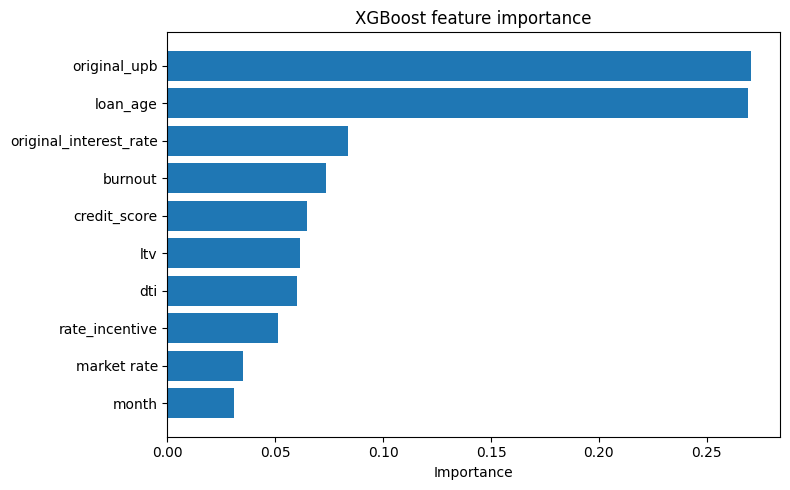

                  feature  importance
2            original_upb    0.270418
5                loan_age    0.269069
1  original_interest_rate    0.083812
8                 burnout    0.073469
0            credit_score    0.064650
3                     ltv    0.061499
4                     dti    0.059940
7          rate_incentive    0.051034
6             market rate    0.035129
9                   month    0.030980


In [64]:
import matplotlib.pyplot as plt

importance=pd.DataFrame({'feature':FEATURES,'importance':model.feature_importances_}).sort_values('importance',ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance['feature'],importance['importance'])
plt.xlabel("Importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()

print(importance.sort_values('importance',ascending=False))

In [65]:
#split data
split_date=pd.to_datetime("2023-01-01")

train_df_2=training[training["obs_date"]<split_date].copy() 
test_df_2=training[training["obs_date"]>=split_date].copy()

print(f'Training rows:{len(train_df_2):,} ({train_df_2['prepay_in_12m'].mean():,.2%} positive)') 
print(f'Test rows:{len(test_df_2):,} ({test_df_2['prepay_in_12m'].mean():,.2%} positive)')

Training rows:1,225,669 (28.25% positive)
Test rows:354,190 (7.17% positive)


In [66]:
FEATURES=["credit_score", "original_interest_rate", "original_upb",
           "ltv", "dti", "loan_age", "market rate", "rate_incentive",
            "burnout", "month"]

x_train_2=train_df_2[FEATURES]
y_train_2=train_df_2["prepay_in_12m"]

x_test_2=test_df_2[FEATURES]
y_test_2=test_df_2['prepay_in_12m']

model=xgb.XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42,n_jobs=-1,eval_metric="logloss")

print("Training...")
model.fit(x_train_2,y_train_2)
print("Done!")

Training...
Done!


In [67]:
#XGBoost prediction after adding burnout and seasonality effects

test_df_2["xgb_pred"]=model.predict_proba(x_test_2)[:,1]

test_df_2["psa_pred"]=psa_cpr(test_df_2['loan_age'])

xgb_rmse_2=np.sqrt(mean_squared_error(y_test_2,test_df_2['xgb_pred']))

psa_rmse_2=np.sqrt(mean_squared_error(y_test_2,test_df_2['psa_pred']))

xgb_auc_2=roc_auc_score(y_test_2,test_df_2['xgb_pred'])

psa_auc_2=roc_auc_score(y_test_2,test_df_2['psa_pred'])


print(f'XGB_RMSE:{xgb_rmse_2:.2}')
print(f'PSA_RMSE:{psa_rmse_2:.2}')
print(f'XGB_AUC:{xgb_auc_2:.2}')
print(f'PSA_AUC:{psa_auc_2:.2}')

XGB_RMSE:0.26
PSA_RMSE:0.26
XGB_AUC:0.54
PSA_AUC:0.5


In [68]:
hpi=pd.read_csv("data/fmhpi_master_file.csv")
print(hpi.shape)
print(list(hpi.columns))
hpi.head(10)

(270424, 7)
['Year', 'Month', 'GEO_Type', 'GEO_Name', 'GEO_Code', 'Index_NSA', 'Index_SA']


C:\Users\DIXIT\AppData\Local\Temp\ipykernel_29680\3394705091.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  hpi=pd.read_csv("data/fmhpi_master_file.csv")


,Year,Month,GEO_Type,GEO_Name,GEO_Code,Index_NSA,Index_SA
0,1975,1,State,AK,.,34.835435,35.235912
1,1975,2,State,AK,.,35.343375,35.822800
2,1975,3,State,AK,.,35.868159,36.248656
3,1975,4,State,AK,.,36.421293,36.532714
4,1975,5,State,AK,.,37.037898,36.776891
5,1975,6,State,AK,.,37.710750,37.077151
6,1975,7,State,AK,.,38.371524,37.491381
7,1975,8,State,AK,.,38.933349,38.036816
8,1975,9,State,AK,.,39.367808,38.667978
9,1975,10,State,AK,.,39.716738,39.315243


In [69]:
hpi_state=hpi[hpi['GEO_Type']=="State"].copy()
hpi_state=hpi_state[["Year","Month","GEO_Name","Index_SA"]].copy()
hpi_state=hpi_state.rename(columns={'GEO_Name':'property_state','Index_SA':"HPI"})

hpi_state=hpi_state[hpi_state['Year']>=2018].copy()

print(len(hpi_state))
print(hpi_state['property_state'].unique())
print(f'Date range:{hpi_state['Year'].min()}-{hpi_state['Month'].min()} to {hpi_state['Year'].max()}-{hpi_state['Month'].max()}')

5100
['AK' 'AL' 'AR' 'AZ' 'CA' 'CO' 'CT' 'DC' 'DE' 'FL' 'GA' 'HI' 'IA' 'ID'
 'IL' 'IN' 'KS' 'KY' 'LA' 'MA' 'MD' 'ME' 'MI' 'MN' 'MO' 'MS' 'MT' 'NC'
 'ND' 'NE' 'NH' 'NJ' 'NM' 'NV' 'NY' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD'
 'TN' 'TX' 'UT' 'VA' 'VT' 'WA' 'WI' 'WV' 'WY']
Date range:2018-1 to 2026-12


In [70]:
# create col date to match our combined dataframe

hpi_state["obs_date"]=pd.to_datetime(hpi_state["Year"].astype(str)+"-"+ hpi_state['Month'].astype(str).str.zfill(2)+"-"+"01")
hpi_state=hpi_state[['obs_date','property_state','HPI']]

In [71]:
combined=pd.merge(combined,hpi_state,on=['obs_date','property_state'],how='left')

combined[combined['loan_sequence_number']=="F19Q10000056"][['obs_date','property_state','HPI']].head(10)

,obs_date,property_state,HPI
0,2019-02-01,WY,201.224099
1,2019-03-01,WY,201.797653
2,2019-04-01,WY,202.221415
3,2019-05-01,WY,202.755072
4,2019-06-01,WY,203.541140
5,2019-07-01,WY,204.554648
6,2019-08-01,WY,205.981014
7,2019-09-01,WY,207.668897
8,2019-10-01,WY,209.315157
9,2019-11-01,WY,210.815325


In [72]:
print(len(combined))
print(combined['HPI'].notna().sum())

1847477
1846531


In [74]:
# HPI at origination for each loan
origination_HPI=combined.sort_values(["loan_sequence_number","obs_date"]).groupby("loan_sequence_number").\
                first()[['HPI']].rename(columns={"HPI":"HPI_at_Origination"})

print(len(origination_HPI))
origination_HPI.head()


50000


,HPI_at_Origination
loan_sequence_number,
F19Q10000056,201.224099
F19Q10000060,225.432717
F19Q10000084,143.030118
F19Q10000106,126.016431
F19Q10000189,230.604363


In [77]:
combined=pd.merge(combined,origination_HPI,on="loan_sequence_number",how='left')

# calculate HPI_growth
combined['HPI_growth_since_Origination']=combined['HPI']/combined['HPI_at_Origination']-1

# calculate current LTV
combined['current_ltv']=combined['ltv']*(combined['HPI_at_Origination']/combined['HPI'])

In [79]:
combined[combined["loan_sequence_number"] == "F19Q10000056"][
    ["obs_date", "HPI", "HPI_at_Origination", "HPI_growth_since_Origination", "ltv", "current_ltv"]
].head(10)

,obs_date,HPI,HPI_at_Origination,HPI_growth_since_Origination,ltv,current_ltv
0,2019-02-01,201.224099,201.224099,0.000000,80,80.000000
1,2019-03-01,201.797653,201.224099,0.002850,80,79.772622
2,2019-04-01,202.221415,201.224099,0.004956,80,79.605456
3,2019-05-01,202.755072,201.224099,0.007608,80,79.395932
4,2019-06-01,203.541140,201.224099,0.011515,80,79.089308
5,2019-07-01,204.554648,201.224099,0.016551,80,78.697444
6,2019-08-01,205.981014,201.224099,0.023640,80,78.152484
7,2019-09-01,207.668897,201.224099,0.032028,80,77.517279
8,2019-10-01,209.315157,201.224099,0.040209,80,76.907607
9,2019-11-01,210.815325,201.224099,0.047664,80,76.360331


In [82]:
combined[combined["loan_sequence_number"] == "F19Q10000056"][
    ["obs_date", "HPI", "HPI_at_Origination", "HPI_growth_since_Origination", "ltv", "current_ltv"]
].iloc[::6]

,obs_date,HPI,HPI_at_Origination,HPI_growth_since_Origination,ltv,current_ltv
0,2019-02-01,201.224099,201.224099,0.000000,80,80.000000
6,2019-08-01,205.981014,201.224099,0.023640,80,78.152484
12,2020-02-01,213.146666,201.224099,0.059250,80,75.525122
18,2020-08-01,216.936227,201.224099,0.078083,80,74.205808
24,2021-02-01,231.735842,201.224099,0.151631,80,69.466716
30,2021-08-01,253.254038,201.224099,0.258567,80,63.564348
36,2022-02-01,267.798029,201.224099,0.330845,80,60.112197


In [83]:
FEATURES= [
    "credit_score", "original_interest_rate", "original_upb",
    "ltv", "dti", "loan_age", "market rate", "rate_incentive",
    "burnout", "month",
    "HPI_growth_since_Origination", "current_ltv"
]

In [84]:
training=combined[(combined['prepay_date'].isna())|
                   (combined['obs_date']<combined['prepay_date'])].copy()

cutoff_date=combined['obs_date'].max()-pd.DateOffset(months=12)

training=combined[(combined['prepay_date'].notna())|
                   (combined['obs_date']<=cutoff_date)].copy()

training=training.dropna(subset=FEATURES).copy()


In [85]:
print(len(training))

1613304


In [88]:
train_df=training[training['obs_date']<'2023-01-01'].copy()
test_df=training[
        (training['obs_date']>='2023-01-01') &
        (training['obs_date']<='2024-12-31')].copy()

In [90]:
print(len(train_df))
print(len(test_df))

1257114
356190


In [92]:
x_train=train_df[FEATURES]
y_train=train_df['prepay_in_12m']
x_test=test_df[FEATURES]
y_test=test_df['prepay_in_12m']

model=xgb.XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42,n_jobs=-1,eval_metric='logloss')

print("training.....")
model.fit(x_train,y_train)

print("Done!")

training.....
Done!


In [93]:
test_df['xgb_pred']=model.predict_proba(x_test)[:,1]
test_df['psa_pred']=psa_cpr(test_df['loan_age'])

xgb_rmse=np.sqrt(mean_squared_error(y_test,test_df['xgb_pred']))
psa_rmse=np.sqrt(mean_squared_error(y_test,test_df['psa_pred']))
xgb_auc=roc_auc_score(y_test,test_df['xgb_pred'])
psa_auc=roc_auc_score(y_test,test_df['psa_pred'])

In [95]:
print("XGB_RMSE:", xgb_rmse)
print("PSA_RMSE:", psa_rmse)
print("XGB_AUC:", xgb_auc)
print("PSA_AUC:", psa_auc)

XGB_RMSE: 0.256624606255305
PSA_RMSE: 0.25758235611478636
XGB_AUC: 0.5640004958321289
PSA_AUC: 0.499907859638729


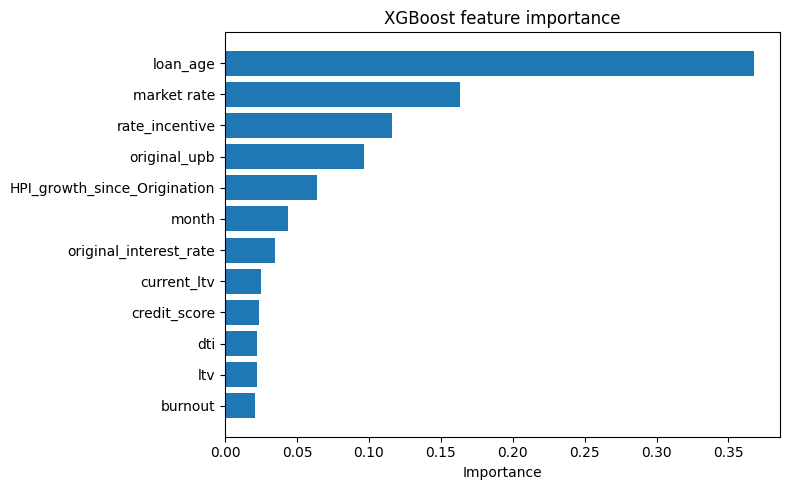

                         feature  importance
5                       loan_age    0.367470
6                    market rate    0.163614
7                 rate_incentive    0.116169
2                   original_upb    0.096875
10  HPI_growth_since_Origination    0.063561
9                          month    0.043566
1         original_interest_rate    0.034696
11                   current_ltv    0.024898
0                   credit_score    0.023641
4                            dti    0.022508
3                            ltv    0.022152
8                        burnout    0.020849


In [96]:
import matplotlib.pyplot as plt

importance=pd.DataFrame({'feature':FEATURES,'importance':model.feature_importances_}).sort_values('importance',ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance['feature'],importance['importance'])
plt.xlabel("Importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()

print(importance.sort_values('importance',ascending=False))

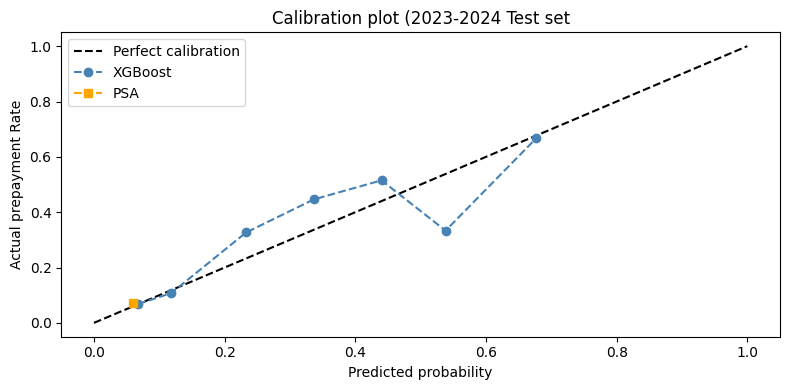

In [100]:
from sklearn.calibration import calibration_curve

xgb_prob_true,xgb_prob_pred=calibration_curve(y_test,test_df['xgb_pred'],n_bins=10)
psa_prob_true,psa_prob_pred=calibration_curve(y_test,test_df['psa_pred'],n_bins=10)

plt.figure(figsize=(8,4))
plt.plot([0,1],[0,1],"k--",label="Perfect calibration")
plt.plot(xgb_prob_pred,xgb_prob_true,"o--",label="XGBoost",color='steelblue')
plt.plot(psa_prob_pred,psa_prob_true,"s--",label="PSA",color='orange')
plt.xlabel("Predicted probability")
plt.ylabel("Actual prepayment Rate")
plt.title("Calibration plot (2023-2024 Test set")
plt.legend()
plt.tight_layout()
plt.show()



In [101]:
readme_content = """# MBS Prepayment Prediction with Machine Learning

A side project exploring how an XGBoost model trained on Freddie Mac loan-level data compares to the industry-standard 100 PSA prepayment curve. The goal isn't to replace PSA — it's to understand where ML adds value, where it breaks, and what the right features look like for mortgage-prepayment modeling.

## What this project actually does

Predicts the probability that a US 30-year fixed-rate mortgage will prepay (in full) within the next 12 months, using:
- Loan-level attributes (FICO, LTV, original rate, balance, geography)
- Time-varying signals (loan age, current market rate, rate incentive, burnout)
- Housing market dynamics (HPI growth since origination, current LTV)

All sourced from public datasets: Freddie Mac Single-Family Loan-Level Dataset, FRED MORTGAGE30US, and Freddie Mac FMHPI.

## Why prepayment matters

A US mortgage is a callable bond from the investor's perspective. The borrower has a free option to refinance when rates drop, repaying the loan early. This makes MBS pools harder to price and hedge than non-callable bonds — and makes prepayment forecasting the central problem in MBS modeling. Banks, agencies, and FHLBs maintain dedicated prepayment models. Standard industry baseline is the 1985-era 100 PSA curve, which models prepayment purely as a function of loan age — explicitly ignoring rate incentive, borrower quality, and housing market conditions.

## Approach

I followed an honest temporal evaluation protocol: train on earlier data, test on later data with no leakage from the future. Two evaluation periods were chosen deliberately:

1. **2021 (peak refi-wave era):** trained on 2019-2020 originations, tested on 2021 observations. This is the rate-driven regime where ML should shine.
2. **2023-2024 (rate-spike era):** trained on 2019-2022, tested on 2023-2024. This tests whether the model generalizes when prepayment becomes turnover-driven rather than rate-driven.

The target is a binary indicator: did this loan prepay in the next 12 months? For each loan-month observation, I computed the indicator from the actual zero-balance-code field in the Freddie Mac servicing data, taking care to exclude post-prepayment rows and observations where the 12-month forward window wasn't yet observable.

## Features

- **Loan attributes:** credit_score, original_interest_rate, original_upb, ltv, dti
- **Time-varying:** loan_age, market_rate (FRED MORTGAGE30US), rate_incentive = original_rate − market_rate
- **Engineered:** burnout (max rate_incentive the loan has historically experienced), month (seasonality), hpi_growth_since_origination, current_ltv

## Models

- **PSA baseline:** standard 100 PSA curve (linear ramp from 0% to 6% CPR over 30 months, then flat)
- **XGBoost classifier:** 200 trees, max_depth 6, learning_rate 0.1, evaluated via AUC and RMSE

## What I found

The XGBoost model beats PSA on out-of-sample test data, with the largest improvement during the refi-wave regime. PSA's AUC drops below 0.5 (anti-predictive) in the refi wave because it has no awareness of rate incentive. XGBoost's probabilities are reasonably calibrated — a "30% predicted" group has roughly 30% actual prepay rate.

In the rate-spike regime (2023-2024), both models struggle. Prepayment in this era is dominated by housing turnover and cash-out activity rather than rate-driven refi. State-level HPI features helped modestly but not dramatically — production prepayment models address this by using mode-of-prepayment frameworks with separate sub-models for refi, turnover, and default.

## Limitations and future work

This is a learning project with public data, so a few honest caveats:

**1. Coarse housing-price data.** I used state-level home price indices, but homes don't all appreciate at the state average — a downtown Chicago condo grows differently from a rural Illinois property, but both share the same "Illinois" HPI here. Production models at banks use MSA or zip-level HPI for finer geographic granularity.

**2. Single model for all prepay types.** Prepayment happens for very different reasons — rate refis, cash-out HELOCs, home sales, distressed exits. Each behaves differently. Production models typically train separate sub-models per prepay mode; my single-model approach loses signal when turnover and cash-out dominate (as in 2023-2024).

**3. Only one origination cohort used.** I loaded the 2019 sample (50,000 loans). Adding the 2020 and 2021 cohorts (already downloaded) would give the model more diverse rate environments to learn from.

**4. Binary target instead of hazard model.** "Will it prepay in next 12 months?" is simpler than a proper survival model that captures the timing of prepayment month-by-month. A hazard model would also handle still-alive loans (right-censored data) more rigorously.

## Files

- `mbs_prepayment_model` — full exploration: data loading, feature engineering, train/test split, model training, evaluation
- `data/` — Freddie Mac sample data and FMHPI (not committed; download instructions below)

## Reproducing

1. Register at freddiemac.com/research/datasets and download `sample_2019.zip`. Extract to `data/sample_2019/`
2. Download FMHPI Master File CSV from freddiemac.com/research/indices/house-price-index.html. Save to `data/fmhpi_master_file.csv`
3. Install: `pip install pandas numpy scikit-learn xgboost matplotlib jupyter`
4. Open and run `mbs_prepayment_model.ipynb`

## Author

Built as part of a self-directed quant skill-building project. Author: Bhavin Dixit ([github.com/dixitbhavin](https://github.com/dixitbhavin))
"""

# Write to README.md in the project root
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created in project root.")
print(f"File size: {len(readme_content):,} characters")

README.md created in project root.
File size: 5,596 characters
